In [1]:
from lets_plot import *
from lets_plot import tilesets
from lets_plot.geo_data import *

The geodata is provided by © OpenStreetMap contributors and is made available here under the Open Database License (ODbL).



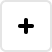
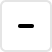
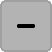
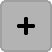
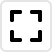
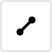
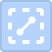
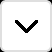
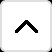
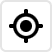
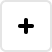
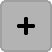
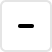
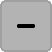
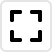
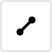
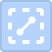
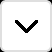
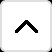
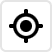

In [2]:
LetsPlot.setup_html()

In [3]:
plot_side = 600

In [4]:
colors = dict(
    light=dict(
        geom="#474747",
        background="white",
    ),
    dark=dict(
        geom="white",
        background="#14181e",
    ),
)

## Charts

In [5]:
def get_charts_data():
    return [0] * 1 + [1] * 3 + [2] * 5 + [3] * 5 + [4] * 5 + [5] * 3 + [6] * 1

In [6]:
def get_charts_preview(*, theme_type):
    return ggplot() + \
        geom_ydotplot(aes(y=get_charts_data()), dotsize=3, stackratio=2.2, fill=colors[theme_type]["geom"], stroke=0) + \
        ggsize(plot_side, plot_side) + \
        theme_void() + theme(plot_background=element_rect(fill=colors[theme_type]["background"]))

In [7]:
get_charts_preview(theme_type='light')

In [8]:
get_charts_preview(theme_type='dark')

## Maps

In [9]:
def get_maps_preview(*, theme_type):
    if theme_type == 'light':
        tiles = tilesets.LETS_PLOT_LIGHT
    elif theme_type == 'dark':
        tiles = tilesets.LETS_PLOT_DARK
    else:
        tiles = tilesets.LETS_PLOT_COLOR
    return ggplot() + \
        geom_livemap(location=[18, 5], zoom=3, tiles=tiles) + \
        ggsize(plot_side, plot_side)

In [10]:
get_maps_preview(theme_type='light')

In [11]:
get_maps_preview(theme_type='dark')

## Geocoding

In [12]:
delta = 16
xmin = 129.5
xmax = xmin + delta
ymin = 30
ymax = ymin + delta

In [13]:
def get_geocoding_data():
    country = "Japan"
    bbox = geocode_countries(names=country)
    return geocode_states().scope(bbox).inc_res(4).get_boundaries()

In [14]:
def get_geocoding_preview(*, theme_type):
    return ggplot() + \
        geom_map(data=get_geocoding_data(), fill=colors[theme_type]["geom"], color=colors[theme_type]["background"]) + \
        coord_fixed(ratio=1, xlim=[xmin, xmax], ylim=[ymin, ymax]) + \
        ggsize(plot_side, plot_side) + \
        theme_void() + theme(plot_background=element_rect(fill=colors[theme_type]["background"]))

In [15]:
get_geocoding_preview(theme_type='light')

In [16]:
get_geocoding_preview(theme_type='dark')